# Alternatif Genişletilmiş Finansal Ağ Analizi

Bu notebook ana projenin yapısını koruyan ama ondan tamamen ayrı çalışan bir deneme alanıdır. Burada yalnızca belirlediğim ek finansal varlıkları ekleyerek ağ yapısının nasıl değişeceğini incelemek istiyorum.

Bu dosyanın veri ve çıktı bağlantısı sadece `alternative_experiments` klasörünün içindedir. Ana proje klasöründeki `data`, `outputs`, `report` veya ana notebook dosyalarına okuma/yazma yapılmaz.


## 1. Kurulum, Kütüphaneler ve Tam İzole Dosya Yolları

Analize başlarken gerekli kütüphaneleri ve dosya yollarını tanımladım. Bu alternatif sürümde bütün yollar özellikle `alternative_experiments` klasörünün içine sabitlendi. Veri dosyası da çıktılar da yalnızca bu klasör altında oluşur.


In [108]:
# HATIRLATICI: Kutuphaneler yuklenir ve tum yollar sadece alternative_experiments icine sabitlenir.

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import seaborn as sns
import networkx as nx

try:
    import community as community_louvain
except ImportError:
    community_louvain = None
    print("Uyari: python-louvain paketi bu kernelde yok. Topluluk hucrelerine gelmeden once kurmak gerekir.")

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

CURRENT_DIR = Path.cwd().resolve()
candidate_dirs = [CURRENT_DIR]
candidate_dirs.extend(CURRENT_DIR.parents)

BASE_DIR = None
for candidate in candidate_dirs:
    if candidate.name == "alternative_experiments":
        BASE_DIR = candidate
        break
    nested = candidate / "alternative_experiments"
    if nested.exists():
        BASE_DIR = nested
        break

if BASE_DIR is None:
    BASE_DIR = CURRENT_DIR / "alternative_experiments"
    BASE_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH = BASE_DIR / "data" / "raw" / "financial_prices_expanded_2014_2024.csv"
RETURNS_PATH = BASE_DIR / "data" / "processed" / "returns_expanded_2014_2024.csv"
PRE_CRISIS_PATH = BASE_DIR / "data" / "processed" / "returns_expanded_pre_crisis.csv"
POST_CRISIS_PATH = BASE_DIR / "data" / "processed" / "returns_expanded_post_crisis.csv"
CORR_PATH = BASE_DIR / "outputs" / "metrics" / "correlation_matrix_expanded.csv"
EDGE_PATH = BASE_DIR / "data" / "edges" / "network_edges_expanded.csv"

GRAPH_DIR = BASE_DIR / "outputs" / "graphs"
HEATMAP_DIR = BASE_DIR / "outputs" / "heatmaps"
METRICS_DIR = BASE_DIR / "outputs" / "metrics"

for directory in [RAW_PATH.parent, RETURNS_PATH.parent, EDGE_PATH.parent, GRAPH_DIR, HEATMAP_DIR, METRICS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

THRESHOLD = 0.40
START_DATE = "2014-01-01"
END_DATE = "2024-12-31"

print(f"Calisma dizini: {CURRENT_DIR}")
print(f"Alternatif deney klasoru: {BASE_DIR}")
print(f"Ham veri dosyasi: {RAW_PATH}")


Calisma dizini: C:\Users\hp\Desktop\social-network-finance\alternative_experiments
Alternatif deney klasoru: C:\Users\hp\Desktop\social-network-finance\alternative_experiments
Ham veri dosyasi: C:\Users\hp\Desktop\social-network-finance\alternative_experiments\data\raw\financial_prices_expanded_2014_2024.csv


## 2. Finansal Varlıklar ve Veri Kaynağı

Bu alternatif sürümde ana projedeki varlık yapısı korunur; veri sağlayıcıdan düzenli şekilde alınabilen ek göstergeler veri setine dahil edilir. Önceki denemede veri alınamayan bazı semboller listeden çıkarıldı. Bunun yerine Yahoo Finance üzerinden daha yüksek olasılıkla veri alınabilen BIST30, seçili BIST hisseleri, TRY bazlı para birimleri ve ek emtialar eklendi.

Para birimi tarafında USD_TRY ve EUR_TRY doğrudan alınır. GBP_TRY, SAR_TRY ve RUB_TRY ise veri uyumluluğu için ara paritelerden hesaplanır. Bu sayede para birimleri ağda USD bazlı değil, Türk lirası karşılığıyla yer alır.


In [109]:
# HATIRLATICI: Ana varliklara BIST30, secili BIST hisseleri, TRY bazli para birimleri, ek emtialar ve CSI300 ekleniyor.

TICKERS = {
    "Gold": "GC=F",
    "Silver": "SI=F",
    "Platinum": "PL=F",
    "Copper": "HG=F",
    "Brent_Oil": "BZ=F",
    "WTI_Oil": "CL=F",
    "Natural_Gas": "NG=F",

    "SP500": "^GSPC",
    "NASDAQ": "^IXIC",
    "Dow_Jones": "^DJI",
    "DAX": "^GDAXI",
    "FTSE100": "^FTSE",
    "Nikkei225": "^N225",

    "BIST100": "XU100.IS",
    "BIST30": "XU030.IS",
    "BIST_Banks": "XBANK.IS",
    "BIST_Industrials": "XUSIN.IS",

    "THYAO": "THYAO.IS",
    "GARAN": "GARAN.IS",
    "AKBNK": "AKBNK.IS",
    "ISCTR": "ISCTR.IS",
    "KCHOL": "KCHOL.IS",
    "SAHOL": "SAHOL.IS",
    "TUPRS": "TUPRS.IS",
    "ASELS": "ASELS.IS",
    "BIMAS": "BIMAS.IS",

    "USD_TRY": "TRY=X",
    "EUR_TRY": "EURTRY=X",
    "GBP_USD_RAW": "GBPUSD=X",
    "USD_SAR_RAW": "SAR=X",
    "USD_RUB_RAW": "RUB=X",
    "Bitcoin": "BTC-USD",
    "VIX": "^VIX",
    "US_10Y_Bond": "^TNX",
    "Dollar_Index": "DX-Y.NYB",

    "CSI300": "000300.SS",
    "MOEX_Russia": "IMOEX.ME",
}

SYNTHETIC_ASSETS = ["GBP_TRY", "SAR_TRY", "RUB_TRY"]

ASSET_DESCRIPTIONS = {
    "Platinum": "Platin vadeli işlem fiyatı",
    "Copper": "Bakır vadeli işlem fiyatı",
    "BIST30": "Borsa İstanbul’daki en büyük 30 şirket endeksi",
    "BIST_Banks": "Türkiye bankacılık sektörü endeksi",
    "BIST_Industrials": "Sanayi şirketleri endeksi",
    "THYAO": "Türk Hava Yolları hissesi",
    "GARAN": "Garanti BBVA hissesi",
    "AKBNK": "Akbank hissesi",
    "ISCTR": "İş Bankası C hissesi",
    "KCHOL": "Koç Holding hissesi",
    "SAHOL": "Sabancı Holding hissesi",
    "TUPRS": "Tüpraş hissesi",
    "ASELS": "Aselsan hissesi",
    "BIMAS": "BİM Mağazalar hissesi",
    "GBP_TRY": "İngiliz sterlini / Türk lirası kuru",
    "SAR_TRY": "Suudi Arabistan riyali / Türk lirası kuru",
    "RUB_TRY": "Rus rublesi / Türk lirası kuru",
    "CSI300": "Çin’in en büyük 300 şirketini temsil eden endeks",
    "MOEX_Russia": "Moskova Borsası endeksi",
}

display_assets = list(TICKERS.keys()) + SYNTHETIC_ASSETS
pd.DataFrame({
    "Asset": display_assets,
    "Yahoo_Finance_Code": [TICKERS.get(asset, "Sentetik") for asset in display_assets],
    "Description": [ASSET_DESCRIPTIONS.get(asset, "Ana projedeki varlık") for asset in display_assets],
})


,Asset,Yahoo_Finance_Code,Description
0,Gold,GC=F,Ana projedeki varlık
1,Silver,SI=F,Ana projedeki varlık
2,Platinum,PL=F,Platin vadeli işlem fiyatı
3,Copper,HG=F,Bakır vadeli işlem fiyatı
4,Brent_Oil,BZ=F,Ana projedeki varlık
5,WTI_Oil,CL=F,Ana projedeki varlık
6,Natural_Gas,NG=F,Ana projedeki varlık
7,SP500,^GSPC,Ana projedeki varlık
8,NASDAQ,^IXIC,Ana projedeki varlık
9,Dow_Jones,^DJI,Ana projedeki varlık


## 3. Ham Verinin Okunması veya Kendi Klasörüne İndirilmesi

Bu bölüm sadece alternatif klasör içindeki genişletilmiş ham veri dosyasını kontrol eder. Dosya varsa doğrudan onu okur. Dosya yoksa tüm varlık listesini Yahoo Finance üzerinden indirip yine yalnızca `alternative_experiments/data/raw` altına kaydeder.

Burada ana projenin `data` klasöründen okuma yapılmaz ve ana projenin hiçbir çıktı klasörüne dosya yazılmaz.


In [110]:
# HATIRLATICI: Ham veri alternatif klasorde okunur; eksik kalan varliklar tekrar denenir ve TRY bazli sentetik kurlar hesaplanir.

def download_price_data(tickers_to_download):
    import time
    import yfinance as yf

    price_data = pd.DataFrame()
    total_assets = len(tickers_to_download)

    for order, (asset_name, ticker) in enumerate(tickers_to_download.items(), start=1):
        print(f"[{order}/{total_assets}] {asset_name} verisi indiriliyor: {ticker}")
        data = pd.DataFrame()

        for attempt in range(1, 4):
            try:
                data = yf.download(
                    ticker,
                    start=START_DATE,
                    end=END_DATE,
                    progress=False,
                    threads=False,
                    timeout=30,
                    auto_adjust=False,
                )
                if not data.empty:
                    break
            except Exception as error:
                print(f"Uyari: {asset_name} deneme {attempt}/3 basarisiz. Hata: {error}")

            time.sleep(2)

        if data.empty:
            print(f"Uyari: {asset_name} icin veri gelmedi.")
            continue

        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        if "Adj Close" in data.columns:
            price_data[asset_name] = data["Adj Close"]
        elif "Close" in data.columns:
            price_data[asset_name] = data["Close"]
        else:
            print(f"Uyari: {asset_name} icin Close/Adj Close kolonu bulunamadi.")

    return price_data.sort_index()

def add_synthetic_try_rates(price_frame):
    if {"GBP_USD_RAW", "USD_TRY"}.issubset(price_frame.columns):
        price_frame["GBP_TRY"] = price_frame["GBP_USD_RAW"] * price_frame["USD_TRY"]

    if {"USD_SAR_RAW", "USD_TRY"}.issubset(price_frame.columns):
        price_frame["SAR_TRY"] = price_frame["USD_TRY"] / price_frame["USD_SAR_RAW"]

    if {"USD_RUB_RAW", "USD_TRY"}.issubset(price_frame.columns):
        price_frame["RUB_TRY"] = price_frame["USD_TRY"] / price_frame["USD_RUB_RAW"]

    return price_frame

if RAW_PATH.exists():
    prices = pd.read_csv(RAW_PATH, index_col="Date", parse_dates=True).sort_index()
else:
    prices = pd.DataFrame()

RAW_TO_SYNTHETIC = {
    "GBP_USD_RAW": "GBP_TRY",
    "USD_SAR_RAW": "SAR_TRY",
    "USD_RUB_RAW": "RUB_TRY",
}

missing_tickers = {}
for asset, ticker in TICKERS.items():
    synthetic_asset = RAW_TO_SYNTHETIC.get(asset)
    if synthetic_asset and synthetic_asset in prices.columns:
        continue
    if asset not in prices.columns:
        missing_tickers[asset] = ticker

if missing_tickers:
    print("Eksik varliklar tekrar denenecek:", list(missing_tickers.keys()))
    downloaded_prices = download_price_data(missing_tickers)
    prices = prices.join(downloaded_prices, how="outer") if not prices.empty else downloaded_prices

prices = prices.drop(columns=["GBP_USD", "USD_SAR", "USD_RUB"], errors="ignore")
prices = add_synthetic_try_rates(prices)
analysis_assets = [asset for asset in TICKERS if not asset.endswith("_RAW")] + [asset for asset in SYNTHETIC_ASSETS if asset in prices.columns]
prices = prices[[asset for asset in analysis_assets if asset in prices.columns]].sort_index()
prices.to_csv(RAW_PATH)

missing_after_load = [asset for asset in analysis_assets if asset not in prices.columns]
if missing_after_load:
    print("Veri alinamayan varliklar:", missing_after_load)

print("Veri boyutu:", prices.shape)
prices.head()


Veri boyutu: (2849, 37)


,Gold,Silver,Platinum,Copper,Brent_Oil,WTI_Oil,Natural_Gas,SP500,NASDAQ,Dow_Jones,...,EUR_TRY,Bitcoin,VIX,US_10Y_Bond,Dollar_Index,CSI300,MOEX_Russia,GBP_TRY,SAR_TRY,RUB_TRY
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-02,1225.000000,20.098000,1401.900024,3.4315,107.779999,95.440002,4.321,1831.979980,4143.069824,16441.349609,...,2.95518,NaN,14.23,2.985,80.629997,NaN,NaN,3.558886,0.572373,0.065627
2014-01-03,1238.400024,20.181999,1411.500000,3.4060,106.889999,93.959999,4.304,1831.369995,4131.910156,16469.990234,...,2.96316,NaN,13.76,2.995,80.790001,NaN,NaN,3.567009,0.578821,0.065528
2014-01-06,1237.800049,20.077000,1413.699951,3.4120,106.730003,93.430000,4.306,1826.770020,4113.680176,16425.099609,...,2.95804,NaN,13.55,2.961,80.650002,NaN,1463.750000,3.569682,0.580484,0.065578
2014-01-07,1229.400024,19.764999,1412.699951,3.4110,107.349998,93.669998,4.299,1837.880005,4153.180176,16530.939453,...,2.95703,NaN,12.92,2.937,80.830002,NaN,NaN,3.562003,0.578941,0.065461
2014-01-08,1225.300049,19.518000,1412.199951,3.3935,107.150002,92.330002,4.216,1837.489990,4165.609863,16462.740234,...,2.94895,NaN,12.87,2.993,81.040001,NaN,1462.670044,3.552227,0.578070,0.065431


## 4. Veri Ön İşleme

Finansal varlıkların fiyat seviyeleri doğrudan karşılaştırmaya uygun değildir. Bu nedenle analizde ham fiyatlar yerine günlük yüzde getiriler kullanıldı. Alternatif veri setinde bazı yeni varlıkların başlangıç tarihi veya işlem takvimi farklı olduğu için bütün sütunlarda aynı anda eksik değer silmek veri dönemini gereksiz biçimde daraltabilir.

Bu yüzden getiriler her varlık için ayrı hesaplanır; tamamen boş satırlar temizlenir ama bir varlıkta eksik değer var diye diğer varlıkların aynı tarihli gözlemleri atılmaz. Korelasyon hesaplanırken pandas zaten her varlık çifti için ortak tarihleri kullanır. Böylece ana dönem 2014-2024 olarak korunur.


In [111]:
# HATIRLATICI: Ham fiyatlar gunluk getirilere donusturuluyor; eksikler tum donemi daraltmayacak sekilde korunuyor.

analysis_prices = prices.sort_index().copy()
analysis_prices = analysis_prices.loc[START_DATE:END_DATE]
analysis_prices = analysis_prices.dropna(axis=1, how="all")

returns = analysis_prices.pct_change(fill_method=None)
returns = returns.replace([np.inf, -np.inf], np.nan)
returns = returns.dropna(axis=0, how="all")
returns = returns.dropna(axis=1, how="all")

returns.to_csv(RETURNS_PATH)
returns.loc["2014":"2019"].to_csv(PRE_CRISIS_PATH)
returns.loc["2020":"2024"].to_csv(POST_CRISIS_PATH)

valid_observation_counts = returns.notna().sum().sort_values()
summary = pd.DataFrame({
    "Metric": [
        "Start date",
        "End date",
        "Calendar observation count",
        "Asset count",
        "Lowest valid observations",
    ],
    "Value": [
        returns.index.min().date(),
        returns.index.max().date(),
        len(returns),
        returns.shape[1],
        int(valid_observation_counts.min()) if not valid_observation_counts.empty else 0,
    ],
})

display(summary)
display(valid_observation_counts.to_frame("Valid return observations").head(10))


,Metric,Value
0,Start date,2014-01-03
1,End date,2024-12-30
2,Calendar observation count,2845
3,Asset count,37
4,Lowest valid observations,842


,Valid return observations
CSI300,842
MOEX_Russia,2348
Nikkei225,2388
BIST_Banks,2505
BIST_Industrials,2505
Bitcoin,2506
BIST100,2516
FTSE100,2595
DAX,2599
SAR_TRY,2667


## 5. Korelasyon Matrisi

Bu aşamada finansal varlıkların günlük getiri serileri arasındaki Pearson korelasyon katsayıları hesaplanır. Varlık sayısı arttığı için her hücreye sayı yazmak okunabilirliği bozabilir. Bu nedenle genişletilmiş notebookta ana heatmap tam matris olarak çizilir ama sayı anotasyonları kapalı tutulur; en güçlü pozitif ve negatif ilişkiler ayrıca tablo olarak gösterilir.


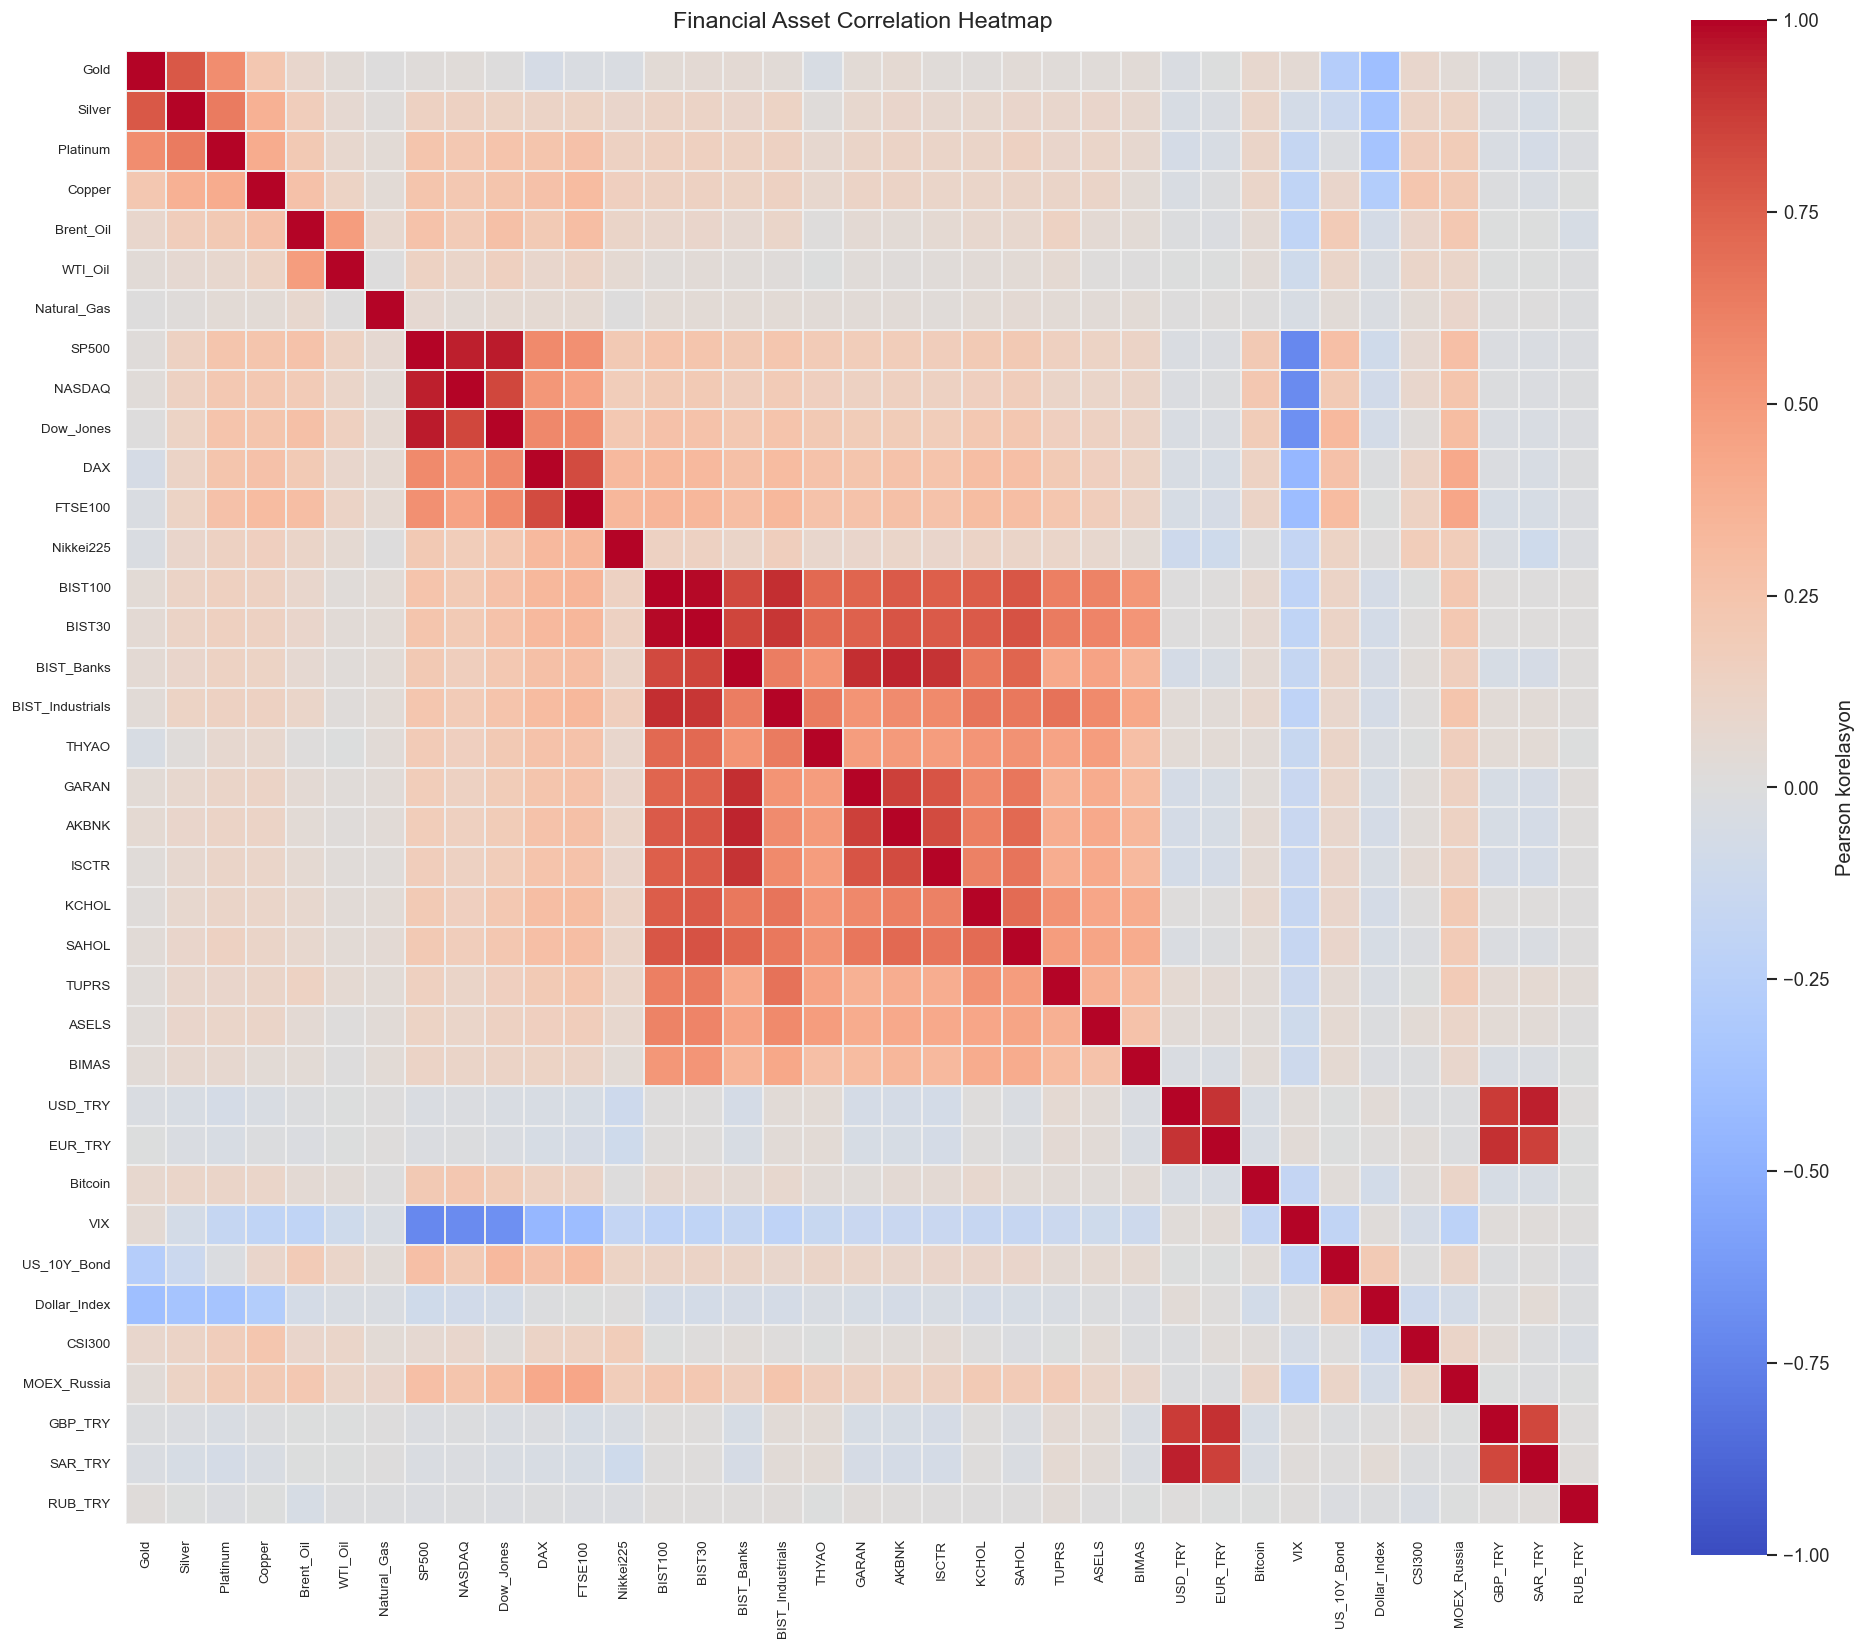

En guclu pozitif iliskiler:


,Asset_1,Asset_2,Correlation,Abs_Correlation
390,BIST100,BIST30,0.991795,0.991795
232,SP500,Dow_Jones,0.954539,0.954539
619,USD_TRY,SAR_TRY,0.950239,0.950239
231,SP500,NASDAQ,0.946344,0.946344
438,BIST_Banks,AKBNK,0.942901,0.942901
392,BIST100,BIST_Industrials,0.920351,0.920351
437,BIST_Banks,GARAN,0.918669,0.918669
627,EUR_TRY,GBP_TRY,0.910805,0.910805
439,BIST_Banks,ISCTR,0.902783,0.902783
611,USD_TRY,EUR_TRY,0.899475,0.899475


En guclu negatif iliskiler:


,Asset_1,Asset_2,Correlation,Abs_Correlation
252,SP500,VIX,-0.716975,0.716975
280,NASDAQ,VIX,-0.698420,0.698420
307,Dow_Jones,VIX,-0.675439,0.675439
333,DAX,VIX,-0.446807,0.446807
358,FTSE100,VIX,-0.407043,0.407043
30,Gold,Dollar_Index,-0.392131,0.392131
65,Silver,Dollar_Index,-0.353962,0.353962
99,Platinum,Dollar_Index,-0.353028,0.353028
132,Copper,Dollar_Index,-0.273820,0.273820
29,Gold,US_10Y_Bond,-0.272034,0.272034


In [112]:
# HATIRLATICI: Korelasyon matrisi hesaplanir; kalabalik aglarda tam heatmap ve en guclu iliski tablolari uretilir.

correlation_matrix = returns.corr(method="pearson")
correlation_matrix = correlation_matrix.dropna(axis=0, how="all").dropna(axis=1, how="all")
correlation_matrix.to_csv(CORR_PATH)

asset_count = len(correlation_matrix)
fig_width = max(14, asset_count * 0.45)
fig_height = max(11, asset_count * 0.42)

plt.figure(figsize=(fig_width, fig_height))
sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    square=True,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.15,
    linecolor="#eeeeee",
    cbar_kws={"label": "Pearson korelasyon", "shrink": 0.85},
)
plt.title("Financial Asset Correlation Heatmap", fontsize=14, pad=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(HEATMAP_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

pair_rows = []
for i, source in enumerate(correlation_matrix.columns):
    for target in correlation_matrix.columns[i + 1:]:
        value = correlation_matrix.loc[source, target]
        if pd.notna(value):
            pair_rows.append({
                "Asset_1": source,
                "Asset_2": target,
                "Correlation": value,
                "Abs_Correlation": abs(value),
            })

correlation_pairs = pd.DataFrame(pair_rows).sort_values("Abs_Correlation", ascending=False)
correlation_pairs.to_csv(METRICS_DIR / "top_correlation_pairs.csv", index=False)

print("En guclu pozitif iliskiler:")
display(correlation_pairs.sort_values("Correlation", ascending=False).head(10))

print("En guclu negatif iliskiler:")
display(correlation_pairs.sort_values("Correlation", ascending=True).head(10))


## 6. Ağ Modelleme

Bu bölümde finansal varlıklar bir graf yapısına dönüştürüldü. Graf yapısında düğümler finansal varlıkları, kenarlar ise varlıklar arasındaki güçlü korelasyon ilişkilerini temsil eder. Matematiksel olarak ağ `G = (V, E)` biçiminde düşünülebilir.

Kurulan ağ yönsüz ve ağırlıklıdır. Yönsüz olmasının nedeni korelasyon ilişkisinin iki taraflı olmasıdır. Ağırlıklı olmasının nedeni ise her kenarın kendi korelasyon katsayısını taşımasıdır. Kenar listesinde bu yüzden `source`, `target` ve `weight` alanları yer alır.

In [113]:
# HATIRLATICI: Korelasyon esigini gecen varlik ciftlerinden yonsuz ve agirlikli ag kuruluyor.

network_assets = list(correlation_matrix.columns)

G = nx.Graph()
G.add_nodes_from(network_assets)

for i, asset_1 in enumerate(network_assets):
    for asset_2 in network_assets[i + 1:]:
        corr_value = correlation_matrix.loc[asset_1, asset_2]
        if pd.notna(corr_value) and abs(corr_value) >= THRESHOLD:
            G.add_edge(asset_1, asset_2, weight=float(corr_value))

edge_df = nx.to_pandas_edgelist(G)
edge_df.to_csv(EDGE_PATH, index=False)

print(f"Node count: {G.number_of_nodes()}")
print(f"Edge count: {G.number_of_edges()}")
edge_df.head(10)


Node count: 37
Edge count: 94


,source,target,weight
0,Gold,Silver,0.781145
1,Gold,Platinum,0.558906
2,Silver,Platinum,0.635234
3,Platinum,Copper,0.403057
4,Brent_Oil,WTI_Oil,0.476657
5,SP500,NASDAQ,0.946344
6,SP500,Dow_Jones,0.954539
7,SP500,DAX,0.572482
8,SP500,FTSE100,0.539655
9,SP500,VIX,-0.716975


## 7. Komşuluk Matrisi ve Aktif Alt Ağ

Komşuluk matrisi, ağdaki düğümlerin birbirleriyle bağlantılı olup olmadığını tablo biçiminde gösterir. Bu çalışmada matris değerleri yalnızca bağlantı varlığını değil, aynı zamanda bağlantının korelasyon ağırlığını da ifade eder.

Korelasyon eşiği uygulandıktan sonra bazı varlıklar ağda izole kalabilir. Yani bu varlıkların seçilen eşik değerine göre yeterince güçlü bağlantısı bulunmayabilir. Bu nedenle hem tüm varlıkları içeren tam ağ hem de yalnızca en az bir bağlantısı bulunan düğümlerden oluşan aktif alt ağ ayrı ayrı incelendi.

In [114]:
# HATIRLATICI: Komsuluk matrisi ve en az bir baglantisi olan dugumlerden aktif alt ag olusturuluyor.

adjacency_matrix = nx.to_pandas_adjacency(G, weight="weight")
active_nodes = [node for node, degree in G.degree() if degree > 0]
active_G = G.subgraph(active_nodes).copy()

print(f"Active node count: {active_G.number_of_nodes()}")
print(f"Active edge count: {active_G.number_of_edges()}")
adjacency_matrix.round(2)

Active node count: 30
Active edge count: 94


,Gold,Silver,Platinum,Copper,Brent_Oil,WTI_Oil,Natural_Gas,SP500,NASDAQ,Dow_Jones,...,EUR_TRY,Bitcoin,VIX,US_10Y_Bond,Dollar_Index,CSI300,MOEX_Russia,GBP_TRY,SAR_TRY,RUB_TRY
Gold,0.00,0.78,0.56,0.0,0.00,0.00,0.0,0.00,0.00,0.00,...,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0
Silver,0.78,0.00,0.64,0.0,0.00,0.00,0.0,0.00,0.00,0.00,...,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0
Platinum,0.56,0.64,0.00,0.4,0.00,0.00,0.0,0.00,0.00,0.00,...,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0
Copper,0.00,0.00,0.40,0.0,0.00,0.00,0.0,0.00,0.00,0.00,...,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0
Brent_Oil,0.00,0.00,0.00,0.0,0.00,0.48,0.0,0.00,0.00,0.00,...,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0
WTI_Oil,0.00,0.00,0.00,0.0,0.48,0.00,0.0,0.00,0.00,0.00,...,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0
Natural_Gas,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00,0.00,...,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0
SP500,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.95,0.95,...,0.00,0.0,-0.72,0.0,0.0,0.0,0.00,0.00,0.00,0.0
NASDAQ,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.95,0.00,0.84,...,0.00,0.0,-0.70,0.0,0.0,0.0,0.00,0.00,0.00,0.0
Dow_Jones,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.95,0.84,0.00,...,0.00,0.0,-0.68,0.0,0.0,0.0,0.00,0.00,0.00,0.0


## 8. Temel Ağ Ölçütleri

Bu bölümde ağın genel yapısını anlamak için temel ölçütler hesaplandı. Düğüm sayısı ağdaki finansal varlık sayısını, kenar sayısı güçlü ilişki sayısını, yoğunluk ise gerçekleşen bağlantıların olası tüm bağlantılara oranını gösterir.

Bileşen sayısı, ağın kaç ayrı parçadan oluştuğunu gösterir. En büyük bileşenin çapı, o bileşen içindeki en uzun en kısa yol hakkında bilgi verir. Ortalama kümeleme katsayısı ise varlıkların kendi yakın çevrelerinde ne kadar kümelendiğini gösterir.

In [115]:
# HATIRLATICI: Tam ag ve aktif alt ag icin temel global ag olcutleri hesaplaniyor.

def graph_summary(graph, label):
    components = list(nx.connected_components(graph))
    largest_component = graph.subgraph(max(components, key=len)).copy() if components else nx.Graph()
    diameter = nx.diameter(largest_component) if largest_component.number_of_nodes() > 1 else 0
    return {
        "Network": label,
        "Nodes": graph.number_of_nodes(),
        "Edges": graph.number_of_edges(),
        "Density": nx.density(graph),
        "Average degree": (2 * graph.number_of_edges() / graph.number_of_nodes()) if graph.number_of_nodes() else 0,
        "Connected components": len(components),
        "Largest component size": largest_component.number_of_nodes(),
        "Largest component diameter": diameter,
        "Average clustering": nx.average_clustering(graph) if graph.number_of_nodes() else 0,
    }

summary_df = pd.DataFrame([
    graph_summary(G, "Full network including isolated nodes"),
    graph_summary(active_G, "Active network excluding isolated nodes"),
])
summary_df.to_csv(METRICS_DIR / "global_network_metrics.csv", index=False)
summary_df

,Network,Nodes,Edges,Density,Average degree,Connected components,Largest component size,Largest component diameter,Average clustering
0,Full network including isolated nodes,37,94,0.141141,5.081081,12,13,2,0.666612
1,Active network excluding isolated nodes,30,94,0.216092,6.266667,5,13,2,0.822155


### Çap ve En Büyük Bileşen Yorumu

Ağ parçalı olduğu için çap değerini tüm ağ için tek seferde hesaplamak doğru olmaz. Bu nedenle çapı en büyük bağlı bileşen üzerinden hesapladım. Bu bileşen, ağ içinde birbirine doğrudan veya dolaylı olarak bağlı en geniş varlık grubunu temsil eder.


In [116]:
# HATIRLATICI: Ag parcali oldugu icin cap en buyuk bagli bilesen uzerinden hesaplaniyor.

largest_component_nodes = sorted(max(nx.connected_components(G), key=len))
largest_component_subgraph = G.subgraph(largest_component_nodes).copy()
largest_component_diameter = nx.diameter(largest_component_subgraph)

print("En büyük bağlı bileşen:", ", ".join(largest_component_nodes))
print("En büyük bağlı bileşen düğüm sayısı:", len(largest_component_nodes))
print("En büyük bağlı bileşen çapı:", largest_component_diameter)


En büyük bağlı bileşen: AKBNK, ASELS, BIMAS, BIST100, BIST30, BIST_Banks, BIST_Industrials, GARAN, ISCTR, KCHOL, SAHOL, THYAO, TUPRS
En büyük bağlı bileşen düğüm sayısı: 13
En büyük bağlı bileşen çapı: 2


## 9. Ağ Görselleştirmesi

Bu bölümde oluşturulan finansal ağ görsel olarak incelendi. Görselde düğüm boyutu ve rengi degree centrality değerine göre belirlendi. Daha fazla bağlantıya sahip olan varlıklar ağ içinde daha büyük ve daha belirgin görünür.

Kenar renkleri ilişkinin yönünü gösterir. Pozitif korelasyonlar kırmızı, negatif korelasyonlar mavi olarak çizildi. Kenar kalınlığı ise ilişkinin gücünü temsil eder. Bu görselleştirme sayesinde bağlantıların yönü ve şiddeti birlikte okunabilir.

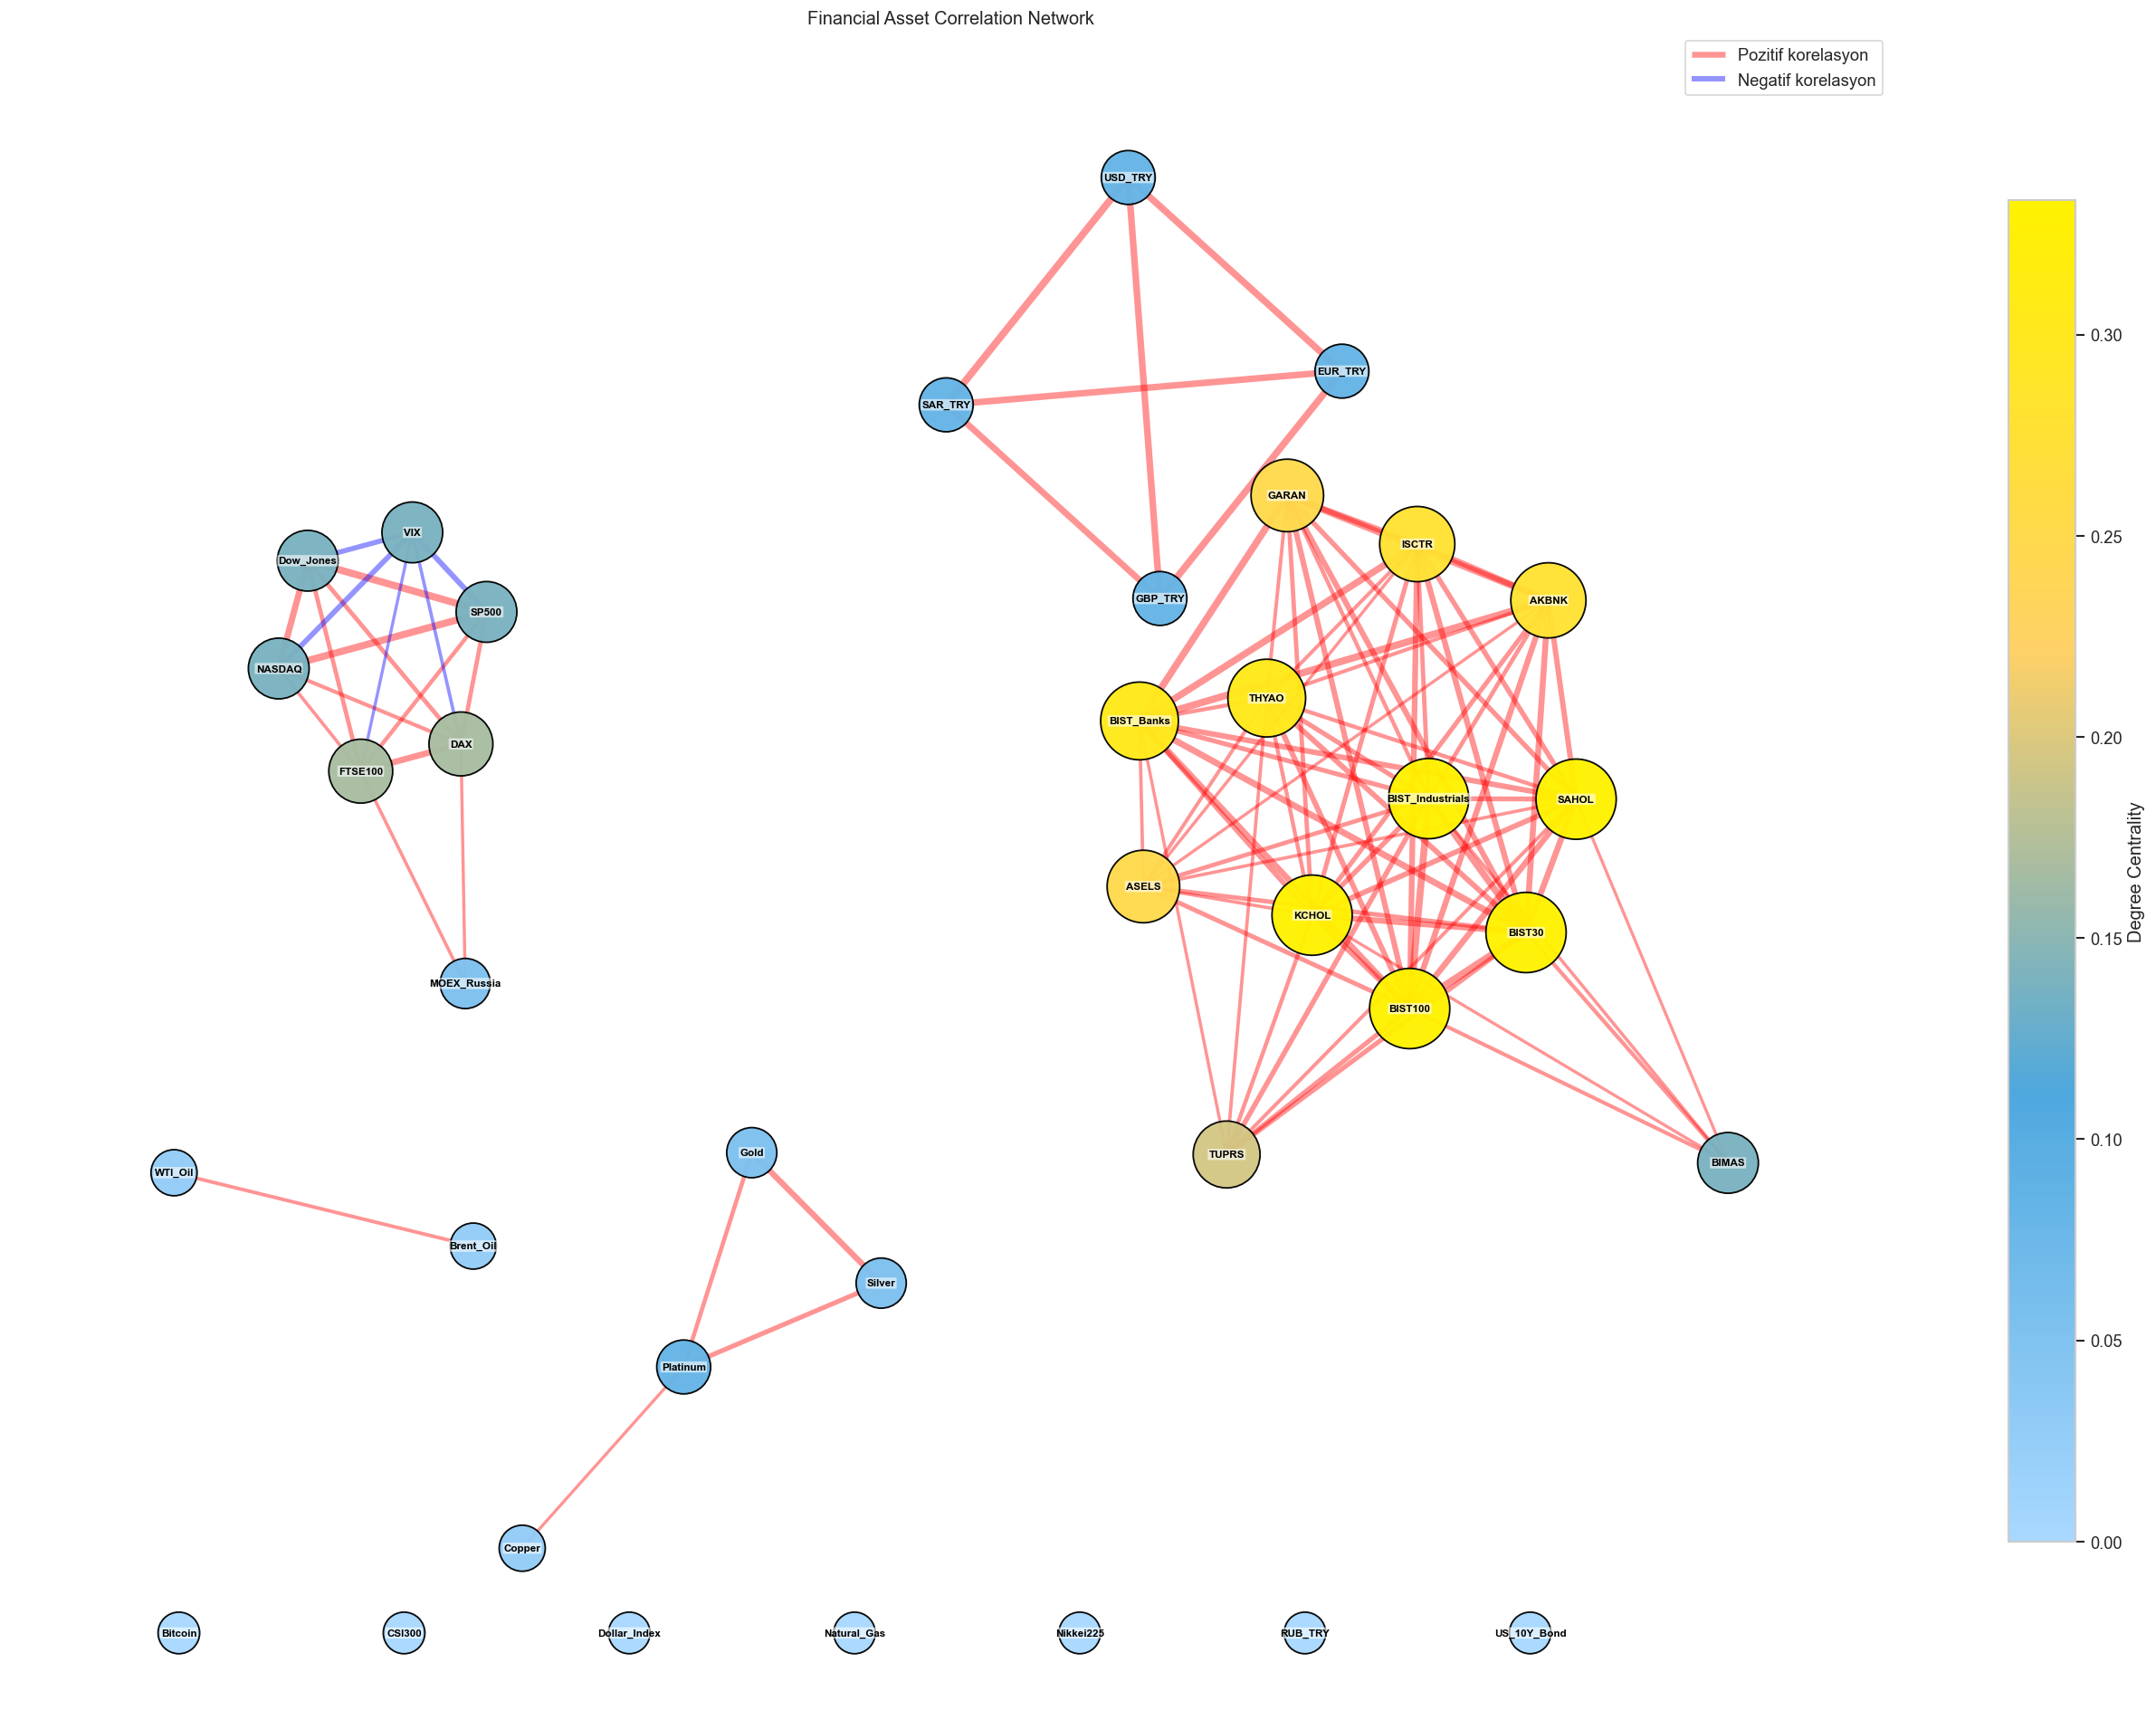

In [117]:
# HATIRLATICI: Ag gorseli bilesenler ayrilarak ciziliyor; tum dugum adlari korunuyor.

degree_centrality = nx.degree_centrality(G)

components = sorted(nx.connected_components(G), key=len, reverse=True)
non_isolated_components = [component for component in components if len(component) > 1]
isolated_nodes = sorted([node for node in G.nodes() if G.degree(node) == 0])

component_centers = [
    (2.2, 0.15),
    (-1.9, 0.65),
    (-0.6, -1.85),
    (1.2, 1.85),
    (-2.2, -1.35),
    (0.0, 2.2),
]

pos = {}
for index, component in enumerate(non_isolated_components):
    subgraph = G.subgraph(component).copy()
    center_x, center_y = component_centers[index % len(component_centers)]
    local_scale = 0.42 + 0.10 * min(len(component), 10)

    if subgraph.number_of_edges() > 0:
        local_pos = nx.spring_layout(
            subgraph,
            seed=42 + index,
            k=1.15,
            iterations=250,
            weight=None,
            scale=local_scale,
        )
    else:
        local_pos = nx.circular_layout(subgraph, scale=local_scale)

    for node, (x, y) in local_pos.items():
        pos[node] = (x + center_x, y + center_y)

if isolated_nodes:
    x_values = np.linspace(-2.8, 2.8, len(isolated_nodes))
    for node, x in zip(isolated_nodes, x_values):
        pos[node] = (x, -3.0)

node_sizes = [degree_centrality[node] * 6200 + 760 for node in G.nodes()]
color_norm = mcolors.Normalize(
    vmin=min(degree_centrality.values()) if degree_centrality else 0,
    vmax=max(degree_centrality.values()) if degree_centrality else 1,
)
color_map = mcolors.LinearSegmentedColormap.from_list(
    "centrality_colors",
    ["#a8d8ff", "#4ea8de", "#ffd166", "#fff200"],
)
node_colors = [color_map(color_norm(degree_centrality[node])) for node in G.nodes()]

positive_edges = [(u, v) for u, v in G.edges() if G[u][v]["weight"] > 0]
negative_edges = [(u, v) for u, v in G.edges() if G[u][v]["weight"] < 0]

plt.figure(figsize=(22, 16))

# Kenarlar once cizilir; dugumler sonra ustune geldigi icin baglantisiz dugumler kenara bagliymis gibi gorunmez.
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=positive_edges,
    width=[abs(G[u][v]["weight"]) * 5.0 for u, v in positive_edges],
    edge_color="red",
    alpha=0.42,
    label="Pozitif korelasyon",
)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=negative_edges,
    width=[abs(G[u][v]["weight"]) * 5.0 for u, v in negative_edges],
    edge_color="blue",
    alpha=0.42,
    label="Negatif korelasyon",
)
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="black",
    linewidths=1.1,
    alpha=0.96,
)
nx.draw_networkx_labels(
    G,
    pos,
    font_size=7,
    font_weight="bold",
    font_color="black",
    bbox={"boxstyle": "round,pad=0.10", "facecolor": "white", "edgecolor": "none", "alpha": 0.58},
)

scalar_mappable = ScalarMappable(norm=color_norm, cmap=color_map)
scalar_mappable.set_array([])
plt.colorbar(scalar_mappable, ax=plt.gca(), label="Degree Centrality", shrink=0.80)
plt.legend(loc="upper right")
plt.title("Financial Asset Correlation Network")
plt.axis("off")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "network_graph_enhanced.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Merkezilik Analizi

Merkezilik ölçütleri, ağ içindeki düğümlerin önemini farklı açılardan değerlendirmeyi sağlar. Degree centrality en çok bağlantıya sahip varlıkları gösterir. Betweenness centrality, farklı düğümler arasındaki yollar üzerinde aracılık eden varlıkları öne çıkarır.

Finansal açıdan bu ölçütler oldukça anlamlıdır. Çok bağlantılı bir endeks piyasanın genel hareketleriyle yakın ilişkili olabilir. Köprü rolündeki bir varlık, farklı piyasa grupları arasında geçiş noktası gibi davranabilir.

In [118]:
# HATIRLATICI: Degree, betweenness, closeness, eigenvector ve clustering metrikleri hesaplaniyor.

centrality_df = pd.DataFrame({
    "Degree_Centrality": pd.Series(nx.degree_centrality(G)),
    "Betweenness_Centrality": pd.Series(nx.betweenness_centrality(G, weight="weight")),
    "Closeness_Centrality": pd.Series(nx.closeness_centrality(G)),
    "Eigenvector_Centrality": pd.Series(nx.eigenvector_centrality(G, max_iter=1000)),
    "Clustering_Coefficient": pd.Series(nx.clustering(G)),
})
centrality_df.to_csv(METRICS_DIR / "network_metrics.csv")
centrality_df.sort_values("Degree_Centrality", ascending=False).head(10)

,Degree_Centrality,Betweenness_Centrality,Closeness_Centrality,Eigenvector_Centrality,Clustering_Coefficient
SAHOL,0.333333,0.001587,0.333333,0.308622,0.818182
KCHOL,0.333333,0.004762,0.333333,0.308622,0.818182
BIST100,0.333333,0.000000,0.333333,0.308622,0.818182
BIST_Industrials,0.333333,0.004762,0.333333,0.308622,0.818182
BIST30,0.333333,0.000000,0.333333,0.308622,0.818182
THYAO,0.305556,0.006349,0.307692,0.295873,0.909091
BIST_Banks,0.305556,0.001587,0.307692,0.295873,0.909091
ISCTR,0.277778,0.000000,0.285714,0.278235,0.977778
AKBNK,0.277778,0.000000,0.285714,0.278235,0.977778
GARAN,0.250000,0.000000,0.266667,0.255999,1.000000


In [119]:
# HATIRLATICI: Her merkezilik olcutu icin ilk 5 dugum tablo olarak gosteriliyor.

top5_tables = {}
for column in ["Degree_Centrality", "Betweenness_Centrality", "Closeness_Centrality", "Eigenvector_Centrality"]:
    top5_tables[column] = centrality_df.sort_values(column, ascending=False).head(5)[[column]]
    print(f"Top 5 - {column}")
    display(top5_tables[column])

Top 5 - Degree_Centrality


,Degree_Centrality
SAHOL,0.333333
KCHOL,0.333333
BIST100,0.333333
BIST_Industrials,0.333333
BIST30,0.333333


Top 5 - Betweenness_Centrality


,Betweenness_Centrality
VIX,0.023016
DAX,0.007937
THYAO,0.006349
BIST_Industrials,0.004762
KCHOL,0.004762


Top 5 - Closeness_Centrality


,Closeness_Centrality
SAHOL,0.333333
KCHOL,0.333333
BIST100,0.333333
BIST_Industrials,0.333333
BIST30,0.333333


Top 5 - Eigenvector_Centrality


,Eigenvector_Centrality
SAHOL,0.308622
KCHOL,0.308622
BIST100,0.308622
BIST_Industrials,0.308622
BIST30,0.308622


## 11. Derece Dağılımı

Derece dağılımı, her düğümün kaç bağlantıya sahip olduğunu gösterir. Bu grafik, ağda bazı varlıkların diğerlerine göre daha fazla ilişki kurup kurmadığını anlamak için kullanıldı.

Finansal ağ bağlamında yüksek dereceye sahip varlıklar, farklı piyasa göstergeleriyle daha fazla birlikte hareket eden varlıklardır. Bu nedenle derece dağılımı, merkezilik tablosunu destekleyen sade bir özet sunar.

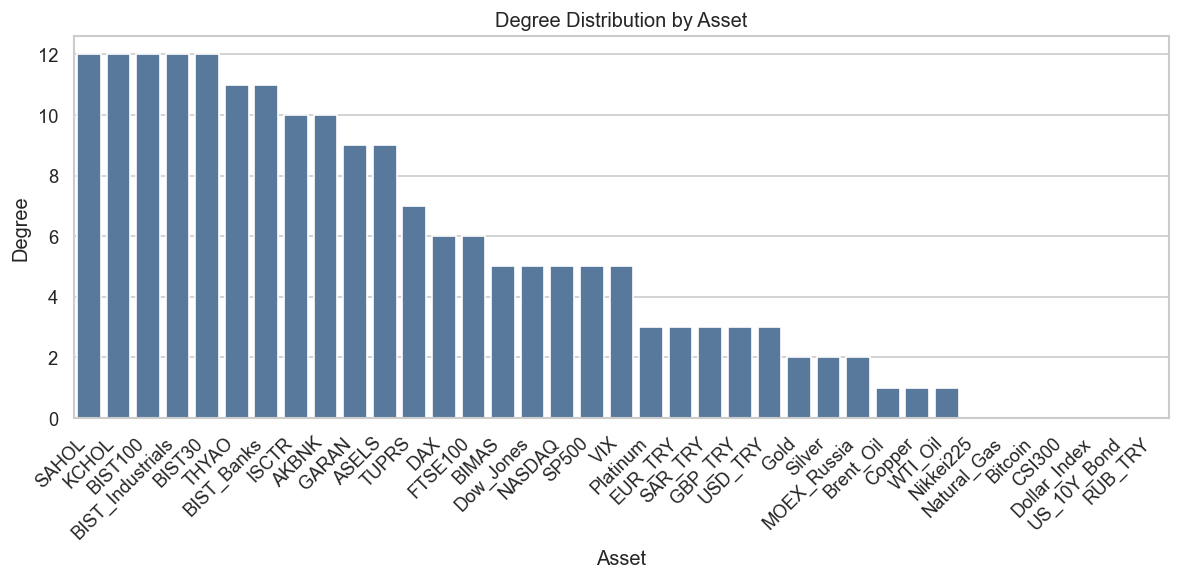

,Degree
SAHOL,12
KCHOL,12
BIST100,12
BIST_Industrials,12
BIST30,12
THYAO,11
BIST_Banks,11
ISCTR,10
AKBNK,10
GARAN,9


In [120]:
# HATIRLATICI: Dugumlerin degree dagilimi bar grafikle gorsellestiriliyor.

degree_series = pd.Series(dict(G.degree()), name="Degree").sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=degree_series.index, y=degree_series.values, color="#4C78A8")
plt.title("Degree Distribution by Asset")
plt.ylabel("Degree")
plt.xlabel("Asset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "degree_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

degree_series.to_frame()

## 12. Topluluk Analizi

Topluluk analizi, ağ içinde birbirleriyle daha yoğun ilişki kuran varlık gruplarını belirlemek için yapıldı. Bu çalışmada Louvain yöntemi kullanıldı. Louvain algoritması, ağdaki bağlantı yapısını dikkate alarak düğümleri birbirine daha yakın gruplar halinde ayırır.

Finansal açıdan topluluklar piyasa segmentlerini yorumlamak için kullanışlıdır. Hisse senedi endekslerinin aynı grupta toplanması, bu piyasaların birlikte hareket ettiğini gösterebilir. Değerli metaller, döviz kurları veya enerji varlıklarının ayrı topluluklar oluşturması ise finansal sistemde farklı alt yapılar bulunduğunu düşündürür.

In [121]:
# HATIRLATICI: Louvain yontemiyle topluluk analizi yapiliyor ve modularity hesaplaniyor.

edge_df = pd.read_csv(EDGE_PATH)

community_G = nx.Graph()

for _, row in edge_df.iterrows():

    corr = row["weight"]

    community_G.add_edge(
        row["source"],
        row["target"],
        weight=abs(corr),
        correlation=corr,
        relation_type="positive" if corr > 0 else "negative"
    )

partition = community_louvain.best_partition(
    community_G,
    weight="weight",
    random_state=42
)

modularity = community_louvain.modularity(
    partition,
    community_G,
    weight="weight"
)

community_df = pd.DataFrame({
    "Node": list(partition.keys()),
    "Community": list(partition.values())
}).sort_values(["Community", "Node"])

community_df.to_csv(
    METRICS_DIR / "community_results.csv",
    index=False
)

print(f"Community count: {community_df['Community'].nunique()}")
print(f"Modularity: {modularity:.4f}")

community_df


Community count: 5
Modularity: 0.4797


,Node,Community
3,Copper,0
0,Gold,0
2,Platinum,0
1,Silver,0
4,Brent_Oil,1
5,WTI_Oil,1
9,DAX,2
8,Dow_Jones,2
10,FTSE100,2
12,MOEX_Russia,2


### En Büyük Topluluk

En büyük topluluğu ayrıca belirlemek istedim, çünkü topluluk sayısını bilmek tek başına yeterli değildir. Hangi grubun ağda daha baskın olduğunu görmek, finansal piyasadaki ana kümeyi yorumlamayı kolaylaştırır.


In [122]:
# HATIRLATICI: En buyuk topluluk ve bu topluluktaki dugumler belirleniyor.

community_sizes = community_df.groupby("Community")["Node"].apply(list)
largest_community_id = community_sizes.apply(len).idxmax()
largest_community_nodes = community_sizes.loc[largest_community_id]

print(f"En büyük topluluk: Community {largest_community_id}")
print("Düğüm sayısı:", len(largest_community_nodes))
print("Düğümler:", ", ".join(largest_community_nodes))


En büyük topluluk: Community 3
Düğüm sayısı: 13
Düğümler: AKBNK, ASELS, BIMAS, BIST100, BIST30, BIST_Banks, BIST_Industrials, GARAN, ISCTR, KCHOL, SAHOL, THYAO, TUPRS


## 13. Topluluk Görselleştirmesi

Bu görselde düğümlerin renkleri ait oldukları toplulukları temsil eder. Aynı renkteki varlıklar, ağ içinde birbirleriyle daha yakın ilişki kuran finansal gruplar olarak yorumlanabilir. Bu sayede topluluk sonuçları ağ yapısı üzerinde de görülebilir.

Topluluk görselleştirmesi finansal segmentlerin ayrışmasını okumayı kolaylaştırır. Hangi varlıkların aynı grupta yer aldığı, hangi grupların daha bağımsız kaldığı ve hangi düğümlerin daha merkezi konumlandığı bu görsel üzerinden daha anlaşılır hale gelir.

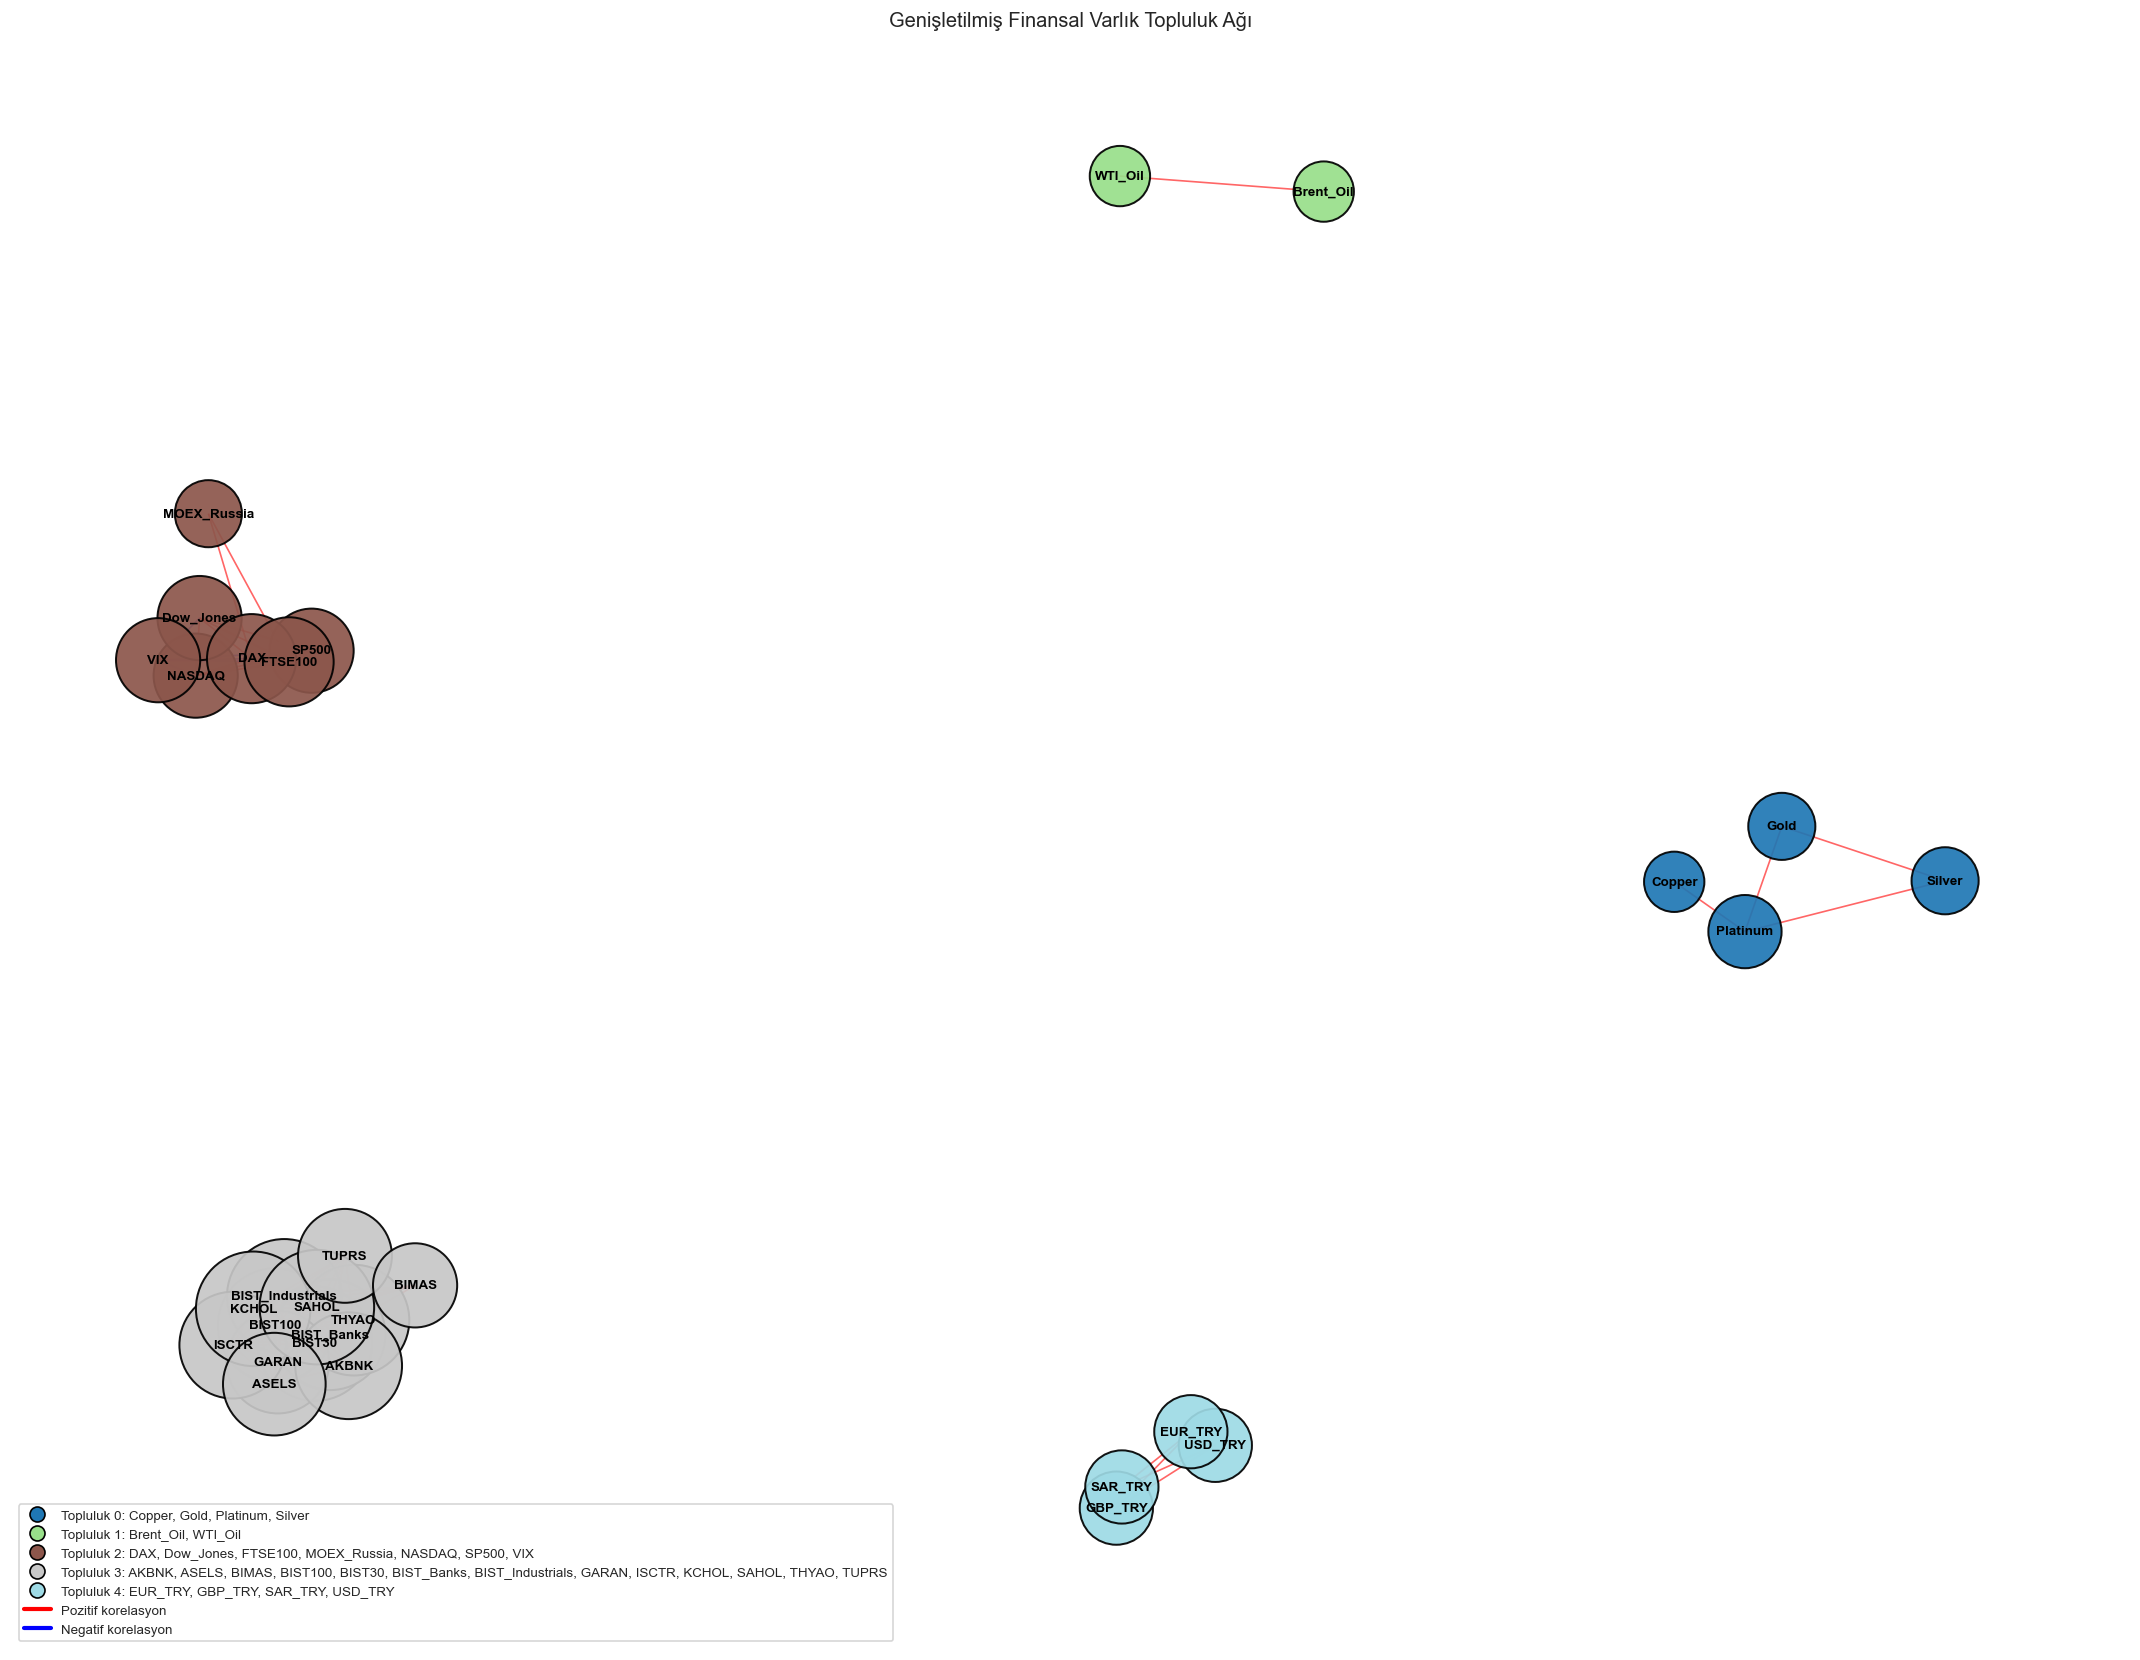

In [123]:
# HATIRLATICI: Topluluklar dinamik renklerle gorsellestiriliyor; topluluk sayisi degisse de kod calisir.

base_pos = nx.spring_layout(
    community_G,
    seed=42,
    k=1.0,
    weight="weight"
)

unique_communities = sorted(set(partition.values()))
angle_values = np.linspace(0, 2 * np.pi, len(unique_communities), endpoint=False)
community_centers = {
    community_id: (2.8 * np.cos(angle), 2.8 * np.sin(angle))
    for community_id, angle in zip(unique_communities, angle_values)
}

pos_comm = {}
for node, (x, y) in base_pos.items():
    comm = partition[node]
    center_x, center_y = community_centers[comm]
    pos_comm[node] = (center_x + x * 0.65, center_y + y * 0.65)

palette = plt.cm.tab20(np.linspace(0, 1, max(len(unique_communities), 1)))
community_colors = {community_id: palette[i] for i, community_id in enumerate(unique_communities)}

community_label_map = (
    community_df.groupby("Community")["Node"]
    .apply(lambda nodes: ", ".join(sorted(nodes)))
    .to_dict()
)

node_colors = [community_colors.get(partition[node], "#777777") for node in community_G.nodes()]
node_sizes = [nx.degree_centrality(community_G)[node] * 9000 + 1000 for node in community_G.nodes()]
positive_edges = [(u, v) for u, v in community_G.edges() if community_G[u][v]["correlation"] > 0]
negative_edges = [(u, v) for u, v in community_G.edges() if community_G[u][v]["correlation"] < 0]

plt.figure(figsize=(18, 14))
nx.draw_networkx_nodes(community_G, pos_comm, node_size=node_sizes, node_color=node_colors, edgecolors="black", linewidths=1.2, alpha=0.92)
nx.draw_networkx_edges(community_G, pos_comm, edgelist=positive_edges, edge_color="red", alpha=0.6)
nx.draw_networkx_edges(community_G, pos_comm, edgelist=negative_edges, edge_color="blue", alpha=0.6)
nx.draw_networkx_labels(community_G, pos_comm, font_size=8, font_weight="bold", font_color="black")

legend_items = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=community_colors[community_id],
        markeredgecolor="black",
        markersize=9,
        label=f"Topluluk {community_id}: {community_label_map.get(community_id, '')}"
    )
    for community_id in unique_communities
]

edge_items = [
    Line2D([0], [0], color="red", lw=2.5, label="Pozitif korelasyon"),
    Line2D([0], [0], color="blue", lw=2.5, label="Negatif korelasyon"),
]

plt.legend(handles=legend_items + edge_items, loc="lower left", frameon=True, fontsize=8)
plt.title("Genişletilmiş Finansal Varlık Topluluk Ağı")
plt.axis("off")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "community_network_expanded.png", dpi=300, bbox_inches="tight")
plt.show()


## 14. Kısa Dayanıklılık Analizi

Bu bölümde ağın merkezi düğümlere karşı nasıl değiştiğini görmek için kısa bir dayanıklılık analizi yapıldı. Önce en yüksek degree centrality değerine sahip düğüm ağdan çıkarıldı. Daha sonra en yüksek betweenness centrality değerine sahip düğüm çıkarılarak ağ ölçütleri yeniden hesaplandı.

Bu senaryonun amacı, kritik görünen bir varlık çıkarıldığında ağın bağlantı yapısının ne kadar değiştiğini anlamaktır. Kenar sayısı, yoğunluk, bileşen sayısı ve en büyük bileşen büyüklüğü karşılaştırıldı.

In [124]:
# HATIRLATICI: En merkezi dugumler cikarilarak kisa dayaniklilik analizi yapiliyor.

def robustness_summary(graph, scenario, removed_node="-"):
    components = list(nx.connected_components(graph))
    return {
        "Scenario": scenario,
        "Removed node": removed_node,
        "Nodes": graph.number_of_nodes(),
        "Edges": graph.number_of_edges(),
        "Density": nx.density(graph),
        "Connected components": len(components),
        "Largest component size": max((len(component) for component in components), default=0),
        "Average clustering": nx.average_clustering(graph) if graph.number_of_nodes() else 0,
    }

top_degree_node = centrality_df["Degree_Centrality"].idxmax()
top_betweenness_node = centrality_df["Betweenness_Centrality"].idxmax()

robustness_rows = [robustness_summary(G, "Original network")]
for scenario, node in [
    ("Remove highest degree node", top_degree_node),
    ("Remove highest betweenness node", top_betweenness_node),
]:
    H = G.copy()
    H.remove_node(node)
    robustness_rows.append(robustness_summary(H, scenario, node))

robustness_df = pd.DataFrame(robustness_rows)
robustness_df.to_csv(METRICS_DIR / "robustness_analysis.csv", index=False)
robustness_df

,Scenario,Removed node,Nodes,Edges,Density,Connected components,Largest component size,Average clustering
0,Original network,-,37,94,0.141141,12,13,0.666612
1,Remove highest degree node,BIST100,36,82,0.130159,12,12,0.656930
2,Remove highest betweenness node,VIX,36,89,0.141270,12,13,0.655499


## 15. Sonuç ve Genel Yorum

Analiz sonucunda finansal varlıkların tamamen dağınık bir yapı oluşturmadığı, belirli piyasa segmentleri etrafında kümelendiği görülmektedir. Küresel hisse senedi endeksleri ve VIX, ağın en belirgin çekirdek yapısını oluşturur. Değerli metaller, döviz kurları ve enerji varlıkları ise daha küçük ve ayrışan gruplar halinde konumlanır.

Bu çalışma, sosyal ağ analizi yaklaşımının finansal piyasaları sistem düzeyinde incelemek için kullanılabileceğini göstermektedir. Korelasyon tabanlı ağ modeli sayesinde hangi varlıkların merkezde yer aldığı, hangi varlıkların köprü rolü oynadığı ve piyasa segmentlerinin nasıl topluluklara ayrıldığı birlikte değerlendirilebilir.